
# Chen-Shu 2015 transport equation example

This notebook reproduces the variable-coefficient transport part of Chen and Shu (2015), Section 6.

The PDE is

$$
 u_t - x u_x = 0, \qquad x\in[-1,1],\qquad u(x,0)=\sqrt{1+x},
$$

with periodic boundary condition of period 2. At final time $T=\log 2$, the exact solution on the recovered subinterval $[-0.5,0]$ is

$$
 u(x,\log 2)=\sqrt{1+2x}.
$$

The table and figures below use a double-precision NumPy translation of the original Fortran `FourierGalerkinTransport` and `gcoe` routines. This intentionally follows the paper/Fortran floating-point path; the high-precision functions in `gegenbauer_reconstruction.py` are useful for verification, but give slightly different last digits for the most accurate rows.


In [1]:

from pathlib import Path
import math
import os
import sys
import time
from dataclasses import dataclass

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = Path.cwd()
if not (REPO / 'Gegenbauer_Python').exists():
    REPO = Path('/Users/zcq/PaperCode/Recover')
sys.path.insert(0, str(REPO))

print('repo =', REPO)


repo = /Users/zcq/PaperCode/Recover



## Important parameter convention

The OCR Markdown labels the last pair columns in Table 7 as `(lambda, m)`, but the original optimization program prints

```text
best pair(m,lambda)
```

and the published optimal errors match that Fortran order. This notebook therefore displays pairs as `(m, lambda)`.

There is one extra inconsistency in the linear-choice row for `N=40`: the Markdown table lists the second pair entry as `10`, but the published error `1.01E-02` and order `5.67` are reproduced by `(m=1, lambda=5)`. The table below reports the corrected computational pair and keeps a note of the printed pair.


In [2]:

@dataclass(frozen=True)
class PaperTable7Row:
    N: int
    paper_linear_error: str
    paper_order: str
    printed_linear_pair_m_lambda: tuple[int, int]
    corrected_linear_pair_m_lambda: tuple[int, int]
    paper_optimal_error: str
    paper_optimal_pair_m_lambda: tuple[int, int]
    paper_without_pp_error: str


PAPER_ROWS = [
    PaperTable7Row(10, '6.93E-01', '',     (0, 3),  (0, 3),  '5.81E-01', (1, 2),  '6.57E-01'),
    PaperTable7Row(20, '5.13E-01', '0.43', (0, 5),  (0, 5),  '1.72E-01', (1, 8),  '5.04E-01'),
    PaperTable7Row(40, '1.01E-02', '5.67', (1, 10), (1, 5),  '7.34E-03', (1, 6),  '4.45E-01'),
    PaperTable7Row(80, '2.61E-05', '8.60', (1, 20), (1, 20), '2.61E-05', (1, 20), '4.07E-01'),
]


def sci(value, digits=3):
    return f'{float(value):.{digits}E}'


def order(previous, current):
    if previous is None:
        return ''
    return f'{math.log(previous / current, 2):.2f}'


In [3]:

class TransportFGDouble:
    """Double-precision translation of the Fortran transport and gcoe path."""

    def __init__(self, n, a=-0.5, b=0.0, q=2):
        self.n = int(n)
        self.a = float(a)
        self.b = float(b)
        self.q = int(q)
        self.indices = np.arange(-self.n, self.n + 1, dtype=int)
        self.coeffs = self._fourier_galerkin_coefficients()

    @staticmethod
    def _periodic_two(value):
        return value - np.trunc(value / 2.0) * 2.0

    @classmethod
    def fs(cls, z):
        z = np.asarray(z, dtype=float)
        tt = cls._periodic_two(z + 3.0)
        return np.where(np.abs(tt) >= 1e-16, np.sqrt(tt), 0.0)

    @classmethod
    def fv(cls, z):
        z = np.asarray(z, dtype=float)
        tt = cls._periodic_two(2.0 * z + 3.0)
        return np.where(np.abs(tt) >= 1e-16, np.sqrt(tt), 0.0)

    def y_to_x(self, y):
        y = np.asarray(y, dtype=float)
        beta = 1.0 / self.q
        temp = 0.5 * (self.b - self.a) ** beta
        x = (temp * (1.0 + y)) ** (1.0 / beta) + self.a
        x = np.where(np.abs(1.0 + y) < 1e-16, self.a, x)
        x = np.where(np.abs(1.0 - y) < 1e-16, self.b, x)
        return x

    def _initial_fourier_coefficients(self):
        n = self.n
        panel_count = min(100 * n, 4000)
        dx = 1.0 / panel_count
        x1 = math.sqrt(0.6)
        wt1 = (5.0 / 9.0) * dx
        wt0 = (8.0 / 9.0) * dx
        j = np.arange(-panel_count + 1, panel_count, 2, dtype=float)
        xn = (j - x1) * dx
        xm = j * dx
        xp = (j + x1) * dx
        fn = self.fs(xn)
        fm = self.fs(xm)
        fp = self.fs(xp)
        coeffs = np.zeros(2 * n + 1, dtype=np.complex128)
        for k in range(0, n + 1):
            phase_n = np.exp(-1j * k * math.pi * xn)
            phase_m = np.exp(-1j * k * math.pi * xm)
            phase_p = np.exp(-1j * k * math.pi * xp)
            acc = np.sum(wt1 * (fn * phase_n + fp * phase_p) + wt0 * fm * phase_m)
            coeffs[k + n] = 0.5 * acc
            coeffs[-k + n] = np.conj(coeffs[k + n])
        return coeffs

    def _fourier_galerkin_coefficients(self):
        n = self.n
        ak = self._initial_fourier_coefficients()
        idx = self.indices.astype(float)
        a1 = 16.0 * math.log(10.0)
        r1 = int(math.sqrt(2 * n))
        filt = np.exp(-a1 * (idx / n) ** r1)

        I, J = np.meshgrid(self.indices, self.indices, indexing='ij')
        matrix = np.zeros((2 * n + 1, 2 * n + 1), dtype=float)
        mask = I != J
        sign = np.where(((J - I) % 2) == 0, 1.0, -1.0)
        matrix[mask] = J[mask] / (J[mask] - I[mask]) * sign[mask]

        final_time = math.log(2.0)
        dt_initial = 0.5 * final_time / (2 * n + 1)
        t = 0.0
        while t < final_time - 1e-16:
            dt = min(dt_initial, final_time - t)
            ak1 = matrix @ ak
            ak2 = matrix @ (ak + 0.5 * dt * ak1)
            ak3 = matrix @ (ak + 0.5 * dt * ak2)
            ak4 = matrix @ (ak + dt * ak3)
            ak = (ak + dt * (ak1 + 2.0 * ak2 + 2.0 * ak3 + ak4) / 6.0) * filt
            t += dt
        return ak

    @staticmethod
    def _rising_over_factorial(lam, max_order):
        values = np.ones(max_order + 1, dtype=float)
        for j in range(1, max_order + 1):
            values[j] = values[j - 1] * (lam + j - 1) / j
        return values

    @staticmethod
    def _gegenbauer_grid(order, nn, gt):
        theta = math.pi * np.arange(nn + 1, dtype=float) / nn
        values = np.zeros(nn + 1, dtype=float)
        for j in range(order + 1):
            values += gt[j] * gt[order - j] * np.cos(theta * (order - 2 * j))
        return values

    @staticmethod
    def _gegenbauer_norm(order, lam):
        return (
            math.pi
            * 0.5 ** (2 * lam - 1)
            * math.gamma(order + 2 * lam)
            / ((order + lam) * math.gamma(lam) ** 2 * math.gamma(order + 1))
        )

    def evaluate_fourier_series(self, x):
        x = np.asarray(x, dtype=float)
        phases = np.exp(1j * math.pi * np.outer(x, self.indices))
        return np.real(phases @ self.coeffs)

    def gegenbauer_coefficients(self, m, lam):
        n = self.n
        nt = 3 * n
        i = np.arange(1, nt, dtype=float)
        xi = np.cos(math.pi * i / nt)
        xr = self.y_to_x(xi)
        ff = self.evaluate_fourier_series(xr)
        gt = self._rising_over_factorial(lam, m)
        hg = np.zeros(m + 1, dtype=float)
        weight_factor = (1.0 - xi) ** lam * (1.0 + xi) ** lam
        for order in range(m + 1):
            cnl = self._gegenbauer_grid(order, nt, gt)[1:nt]
            acc = np.sum(cnl * ff * weight_factor)
            hg[order] = acc * math.pi / nt / self._gegenbauer_norm(order, lam)
        return hg

    def reconstruction(self, m, lam, nzn=None):
        nzn = self.n if nzn is None else int(nzn)
        y = np.cos(math.pi * np.arange(nzn + 1, dtype=float) / nzn)
        x = self.y_to_x(y)
        hg = self.gegenbauer_coefficients(m, lam)
        gt = self._rising_over_factorial(lam, m)
        values = np.zeros(nzn + 1, dtype=float)
        for order, coeff in enumerate(hg):
            values += coeff * self._gegenbauer_grid(order, nzn, gt)
        exact = self.fv(x)
        errors = np.abs(values - exact)
        return {
            'N': self.n,
            'm': m,
            'lambda': lam,
            'x': x,
            'y': y,
            'values': values,
            'exact': exact,
            'errors': errors,
            'max_error': float(np.max(errors)),
            'x_at_max': float(x[int(np.argmax(errors))]),
        }

    def without_postprocessing(self, nzn=None):
        nzn = self.n if nzn is None else int(nzn)
        y = np.cos(math.pi * np.arange(nzn + 1, dtype=float) / nzn)
        x = self.y_to_x(y)
        values = self.evaluate_fourier_series(x)
        exact = self.fv(x)
        errors = np.abs(values - exact)
        return {
            'N': self.n,
            'x': x,
            'y': y,
            'values': values,
            'exact': exact,
            'errors': errors,
            'max_error': float(np.max(errors)),
            'x_at_max': float(x[int(np.argmax(errors))]),
        }

    def best_reconstruction(self, max_m=None, max_lam=None, nzn=None):
        max_m = self.n // 2 if max_m is None else int(max_m)
        max_lam = self.n // 2 if max_lam is None else int(max_lam)
        nzn = self.n if nzn is None else int(nzn)
        y = np.cos(math.pi * np.arange(nzn + 1, dtype=float) / nzn)
        x = self.y_to_x(y)
        exact = self.fv(x)
        best = None
        for lam in range(1, max_lam + 1):
            hg = self.gegenbauer_coefficients(max_m, lam)
            gt = self._rising_over_factorial(lam, max_m)
            values = np.zeros(nzn + 1, dtype=float)
            for m in range(max_m + 1):
                values += hg[m] * self._gegenbauer_grid(m, nzn, gt)
                errors = np.abs(values - exact)
                max_error = float(np.max(errors))
                if best is None or max_error < best['max_error']:
                    best = {
                        'N': self.n,
                        'm': m,
                        'lambda': lam,
                        'x': x.copy(),
                        'y': y.copy(),
                        'values': values.copy(),
                        'exact': exact.copy(),
                        'errors': errors.copy(),
                        'max_error': max_error,
                        'x_at_max': float(x[int(np.argmax(errors))]),
                    }
        return best



## Table 7 reproduction

The default run computes Fourier-Galerkin coefficients once per `N`, evaluates the unprocessed solution, computes the corrected linear-choice row, and scans `0 <= m <= N/2`, `1 <= lambda <= N/2` for the optimal post-processing pair.


In [4]:

N_VALUES = [10, 20, 40, 80]

computed = {}
rows_for_display = []
previous_linear = None

started_all = time.time()
for paper in PAPER_ROWS:
    if paper.N not in N_VALUES:
        continue
    started = time.time()
    solver = TransportFGDouble(paper.N)
    without = solver.without_postprocessing()
    linear_m, linear_lam = paper.corrected_linear_pair_m_lambda
    linear = solver.reconstruction(linear_m, linear_lam)
    optimal = solver.best_reconstruction()
    elapsed = time.time() - started

    computed[paper.N] = {
        'paper': paper,
        'solver': solver,
        'without': without,
        'linear': linear,
        'optimal': optimal,
        'seconds': elapsed,
    }

    rows_for_display.append({
        'N': paper.N,
        'linear_error': linear['max_error'],
        'linear_order': order(previous_linear, linear['max_error']),
        'linear_pair': (linear_m, linear_lam),
        'printed_linear_pair': paper.printed_linear_pair_m_lambda,
        'paper_linear_error': paper.paper_linear_error,
        'optimal_error': optimal['max_error'],
        'optimal_pair': (optimal['m'], optimal['lambda']),
        'paper_optimal_error': paper.paper_optimal_error,
        'without_error': without['max_error'],
        'paper_without_error': paper.paper_without_pp_error,
        'seconds': elapsed,
    })
    previous_linear = linear['max_error']
    print(f"N={paper.N:>3}: done in {elapsed:.2f}s")

print(f'total seconds = {time.time() - started_all:.2f}')


N= 10: done in 0.00s
N= 20: done in 0.01s
N= 40: done in 0.06s


N= 80: done in 0.32s
total seconds = 0.39


In [5]:

header = (
    '| N | Linear L∞ | Order | pair `(m,lambda)` | printed pair | Paper linear | '
    'Optimal L∞ | best `(m,lambda)` | Paper optimal | Without PP L∞ | Paper without PP | seconds |\n'
    '|---:|---:|---:|:---:|:---:|---:|---:|:---:|---:|---:|---:|---:|'
)
lines = [header]
for row in rows_for_display:
    lines.append(
        f"| {row['N']} | {sci(row['linear_error'])} | {row['linear_order']} | "
        f"{row['linear_pair']} | {row['printed_linear_pair']} | {row['paper_linear_error']} | "
        f"{sci(row['optimal_error'])} | {row['optimal_pair']} | {row['paper_optimal_error']} | "
        f"{sci(row['without_error'])} | {row['paper_without_error']} | {row['seconds']:.2f} |"
    )

display(Markdown('\n'.join(lines)))


| N | Linear L∞ | Order | pair `(m,lambda)` | printed pair | Paper linear | Optimal L∞ | best `(m,lambda)` | Paper optimal | Without PP L∞ | Paper without PP | seconds |
|---:|---:|---:|:---:|:---:|---:|---:|:---:|---:|---:|---:|---:|
| 10 | 6.900E-01 |  | (0, 3) | (0, 3) | 6.93E-01 | 5.788E-01 | (1, 2) | 5.81E-01 | 6.580E-01 | 6.57E-01 | 0.00 |
| 20 | 5.138E-01 | 0.43 | (0, 5) | (0, 5) | 5.13E-01 | 1.742E-01 | (1, 8) | 1.72E-01 | 5.050E-01 | 5.04E-01 | 0.01 |
| 40 | 1.009E-02 | 5.67 | (1, 5) | (1, 10) | 1.01E-02 | 7.342E-03 | (1, 6) | 7.34E-03 | 4.451E-01 | 4.45E-01 | 0.06 |
| 80 | 2.611E-05 | 8.59 | (1, 20) | (1, 20) | 2.61E-05 | 2.611E-05 | (1, 20) | 2.61E-05 | 4.074E-01 | 4.07E-01 | 0.32 |

In [6]:

# Sanity checks against the reported pair/order convention.
expected_best = {row.N: row.paper_optimal_pair_m_lambda for row in PAPER_ROWS}
for N, data in computed.items():
    got = (data['optimal']['m'], data['optimal']['lambda'])
    print(f'N={N}: best pair (m,lambda) = {got}, paper/Fortran pair = {expected_best[N]}')


N=10: best pair (m,lambda) = (1, 2), paper/Fortran pair = (1, 2)
N=20: best pair (m,lambda) = (1, 8), paper/Fortran pair = (1, 8)
N=40: best pair (m,lambda) = (1, 6), paper/Fortran pair = (1, 6)
N=80: best pair (m,lambda) = (1, 20), paper/Fortran pair = (1, 20)



## Fig. 2 analogue: Fourier-Galerkin solution before post-processing

The left panel plots the unprocessed Fourier-Galerkin numerical solutions on `[-0.5,0]` together with the exact solution. The right panel plots the pointwise absolute errors in logarithmic scale.


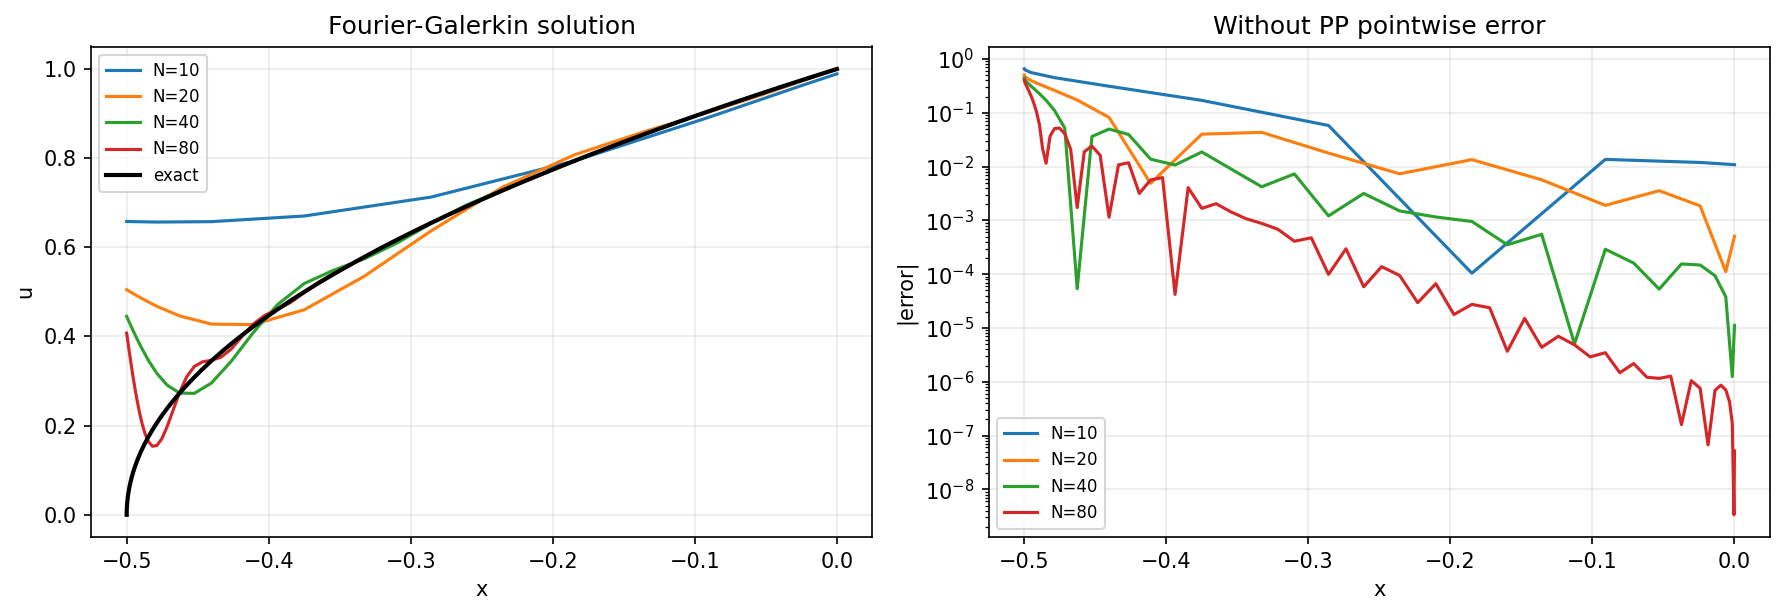

In [7]:

def sorted_xy(result, key='values'):
    order_idx = np.argsort(result['x'])
    return result['x'][order_idx], result[key][order_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=150)
ax = axes[0]
for N, data in computed.items():
    x, values = sorted_xy(data['without'], 'values')
    ax.plot(x, values, linewidth=1.5, label=f'N={N}')
# Exact curve from the finest grid.
x_exact, exact = sorted_xy(computed[max(computed)]['without'], 'exact')
ax.plot(x_exact, exact, color='black', linewidth=2.0, label='exact')
ax.set_title('Fourier-Galerkin solution')
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

ax = axes[1]
for N, data in computed.items():
    x, errors = sorted_xy(data['without'], 'errors')
    ax.semilogy(x, np.maximum(errors, 1e-16), linewidth=1.5, label=f'N={N}')
ax.set_title('Without PP pointwise error')
ax.set_xlabel('x')
ax.set_ylabel('|error|')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()



## Fig. 3 analogue: Gegenbauer post-processing errors

The next figure compares the post-processed pointwise errors for the corrected linear-choice row and the optimal scanned pair.


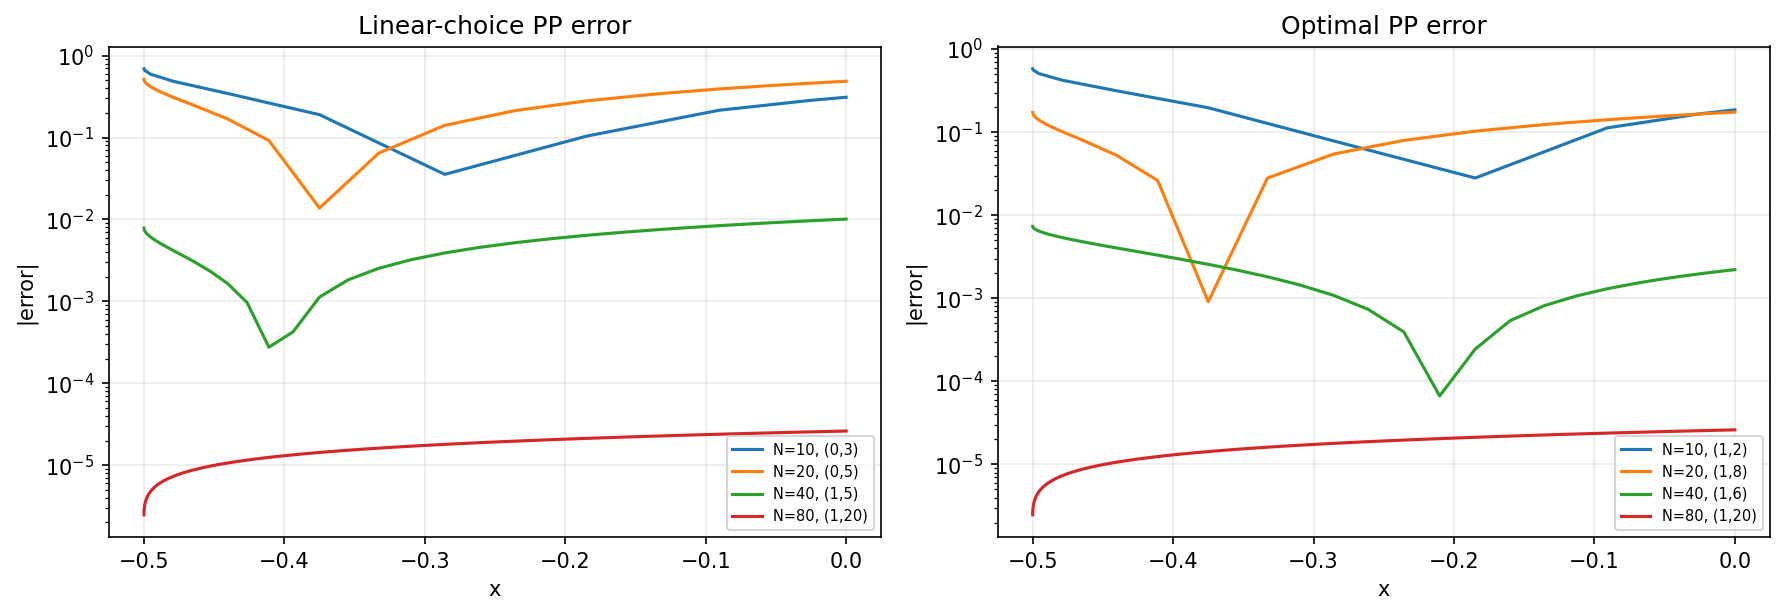

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=150)

ax = axes[0]
for N, data in computed.items():
    x, errors = sorted_xy(data['linear'], 'errors')
    m = data['linear']['m']
    lam = data['linear']['lambda']
    ax.semilogy(x, np.maximum(errors, 1e-16), linewidth=1.5, label=f'N={N}, ({m},{lam})')
ax.set_title('Linear-choice PP error')
ax.set_xlabel('x')
ax.set_ylabel('|error|')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7)

ax = axes[1]
for N, data in computed.items():
    x, errors = sorted_xy(data['optimal'], 'errors')
    m = data['optimal']['m']
    lam = data['optimal']['lambda']
    ax.semilogy(x, np.maximum(errors, 1e-16), linewidth=1.5, label=f'N={N}, ({m},{lam})')
ax.set_title('Optimal PP error')
ax.set_xlabel('x')
ax.set_ylabel('|error|')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()



## Optional high-precision cross-check

The reusable high-precision implementation lives in `Gegenbauer_Python/gegenbauer_reconstruction.py`. For example, the following optional cell checks one row with `mpmath`. It is disabled by default because the high-precision Fourier-Galerkin solve is much slower than the double-precision table reproduction above.


In [9]:

RUN_MPMATH_CROSS_CHECK = False

if RUN_MPMATH_CROSS_CHECK:
    from mpmath import mp
    from Gegenbauer_Python.gegenbauer_reconstruction import (
        fourier_galerkin_transport_coefficients,
        evaluate_transport_fourier_solution,
        reconstruct_variable_transport,
        find_best_transport_parameters,
    )

    mp.dps = 50
    N = 40
    coeffs = fourier_galerkin_transport_coefficients(N)
    without_mp = evaluate_transport_fourier_solution(N, coeffs=coeffs)
    linear_mp = reconstruct_variable_transport(N, m=1, lam=5, coeffs=coeffs)
    best_mp = find_best_transport_parameters(N, coeffs=coeffs, max_m=20, max_lam=20)
    print('mpmath without PP:', mp.nstr(without_mp.max_error, 12))
    print('mpmath linear:', mp.nstr(linear_mp.max_error, 12))
    print('mpmath best:', mp.nstr(best_mp.max_error, 12), (best_mp.best_m, best_mp.best_lam))
else:
    print('Set RUN_MPMATH_CROSS_CHECK = True to run the slower high-precision check.')


Set RUN_MPMATH_CROSS_CHECK = True to run the slower high-precision check.
